In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

%matplotlib inline

**1 - Implemente o algoritmo da iteração de ponto fixo usando somente a biblioteca Numpy.**

In [ ]:
import numpy as np

def metodo_ponto_fixo(g, x0, tol, max_iter=200):
    x_ant = x0
    iteracoes = 0
    erro = 100.0
    convergiu = False

    print(f"{'Iter':<5} {'x_novo':<18} {'Erro (%)':<15}")
    print("-" * 40)

    for i in range(1, max_iter + 1):
        x_novo = g(x_ant)

        if x_novo != 0:
            erro = np.abs((x_novo - x_ant) / x_novo) * 100

        print(f"{i:<5} {x_novo:<18.8f} {erro:<15.6e}")

        if erro <= tol:
            convergiu = True
            iteracoes = i
            break

        x_ant = x_novo
        iteracoes = i

    return x_novo, iteracoes, convergiu

**2 - Use a iteração de ponto fixo simples para localizar a raiz de $f(x)=2\sin(\sqrt{x})-x$, tendo $x_{0}=0,5$ e adotando como critério de parada o erro $e_{a}\le0,001\%$.**

In [ ]:
def g2(x):
    return 2 * np.sin(np.sqrt(x))

x0_q2 = 0.5
tol_q2 = 0.001

raiz, it, conv = metodo_ponto_fixo(g2, x0_q2, tol_q2)

print(f"\nRaiz encontrada: {raiz}")
print(f"Iterações: {it}")

Iter  x_novo             Erro (%)       
----------------------------------------
1     1.29927388         6.151697e+01   
2     1.81714750         2.849926e+01   
3     1.95057392         6.840367e+00   
4     1.96974251         9.731524e-01   
5     1.97206888         1.179659e-01   
6     1.97234418         1.395786e-02   
7     1.97237666         1.646628e-03   
8     1.97238049         1.941869e-04   

Raiz encontrada: 1.9723804860817313
Iterações: 8


**3 - Determine a maior raiz real de $f(x)=2x^{3}-11.7x^{2}+17.7x-5$**

In [ ]:
# Função base para toda a Questão 3
def f3(x):
    return 2*x**3 - 11.7*x**2 + 17.7*x - 5

(a) Graficamente

--- Item (a): Solução Gráfica ---


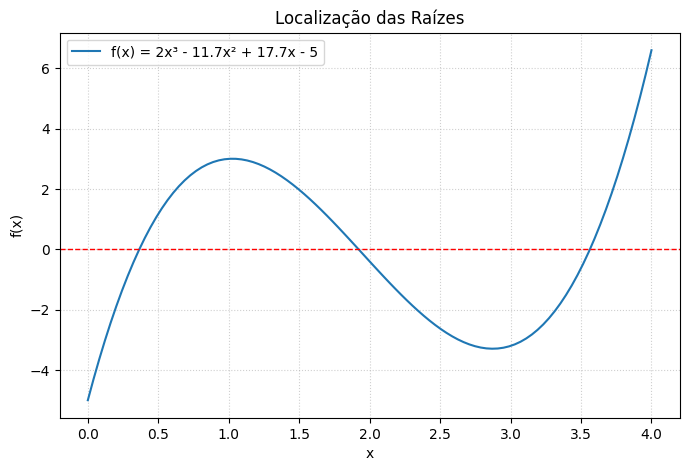

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("--- Item (a): Solução Gráfica ---")

# Intervalo de visualização
x_vals = np.linspace(0, 4, 100)
y_vals = f3(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='f(x) = 2x³ - 11.7x² + 17.7x - 5')
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Linha do zero
plt.grid(True, linestyle=':', alpha=0.6)
plt.title("Localização das Raízes")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

# Pelo gráfico, observamos que a maior raiz está entre 3.0 e 4.0

(b) Pelo método da Bisseção (5 iterações, escolha o intervalo pela visualização gráfica)

In [ ]:
print("--- Item (b): Método da Bisseção (5 iterações) ---")

# Intervalo escolhido visualmente no gráfico anterior
a = 3.0
b = 4.0

print(f"{'Iter':<5} {'a':<10} {'b':<10} {'x_medio':<10} {'f(x_medio)':<15}")
print("-" * 55)

for i in range(1, 6):  # Loop de 1 a 5
    m = (a + b) / 2
    fm = f3(m)

    print(f"{i:<5} {a:<10.4f} {b:<10.4f} {m:<10.4f} {fm:<15.4f}")

    # Lógica da Bisseção: verifica onde ocorre a troca de sinal
    if f3(a) * fm < 0:
        b = m
    else:
        a = m

print("-" * 55)
print(f"Raiz estimada após 5 iterações: {m:.5f}")

--- Item (b): Método da Bisseção (5 iterações) ---
Iter  a          b          x_medio    f(x_medio)     
-------------------------------------------------------
1     3.0000     4.0000     3.5000     -0.6250        
2     3.5000     4.0000     3.7500     2.3125         
3     3.5000     3.7500     3.6250     0.6867         
4     3.5000     3.6250     3.5625     -0.0069        
5     3.5625     3.6250     3.5938     0.3303         
-------------------------------------------------------
Raiz estimada após 5 iterações: 3.59375


(c) Pelo método da iteração de ponto fixo (5 iterações, $x_{0}=3$ - certifique-se de desenvolver uma solução que convirja para a raiz)

In [ ]:
print("--- Item (c): Método do Ponto Fixo (5 iterações) ---")

# Função g(x) manipulada para convergir na maior raiz
def g3(x):
    # Isolando x³: 2x³ = ... -> x = cbrt((...) / 2)
    return np.cbrt((11.7 * x**2 - 17.7 * x + 5) / 2)

x0_q3 = 3.0

# Chama a função criada na Questão 1
# Definimos uma tolerância muito pequena apenas para forçar o loop ir até o max_iter
raiz_pf, it_pf, _ = metodo_ponto_fixo(g3, x0_q3, tol=1e-10, max_iter=5)

print(f"\nResultado final após 5 iterações: {raiz_pf}")

--- Item (c): Método do Ponto Fixo (5 iterações) ---
Iter  x_novo             Erro (%)       
----------------------------------------
1     3.05812578         1.900700e+00   
2     3.11225006         1.739072e+00   
3     3.16219426         1.579416e+00   
4     3.20790672         1.424994e+00   
5     3.24944113         1.278202e+00   

Resultado final após 5 iterações: 3.249441127628292


4 - Compare os métodos da bisseção, falsa posição e do ponto fixo localizando a raiz $x^{*}$ das seguintes equações:

Para as avaliações, deve-se considerar:

* O número máximo de iterações de todos os métodos testados não pode ultrapassar 200;
* A tolerância deve ser de $10^{-10}$;
* Para os métodos abertos, escolha um dos limites do intervalo.

Para cada método, estamos interessados em comparar:
* Raiz
* Número de iterações até o critério de parada
* Se houve erro de convergência
* tempo de cálculo (procure como calcular tempo de execução usando jupyter notebooks, como %timeit).

In [ ]:
import numpy as np
import time

def metodo_ponto_fixo(g, x0, tol, max_iter=200):
    x_ant = x0
    iteracoes = 0
    erro = 100.0
    convergiu = False

    for i in range(1, max_iter + 1):
        x_novo = g(x_ant)
        if x_novo != 0:
            erro = np.abs((x_novo - x_ant) / x_novo) * 100

        if erro <= tol:
            convergiu = True
            iteracoes = i
            return x_novo, iteracoes, convergiu

        x_ant = x_novo
        iteracoes = i

    return x_ant, iteracoes, convergiu

def metodo_bissecao(f, a, b, tol, max_iter=200):
    start_time = time.time()
    iteracoes = 0
    raiz = 0
    convergiu = False

    if f(a) * f(b) >= 0:
        return None, 0, False, 0.0

    for i in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)

        if (b - a) / 2 < tol or abs(fc) < tol:
            raiz = c
            iteracoes = i
            convergiu = True
            break

        if f(a) * fc < 0:
            b = c
        else:
            a = c

        iteracoes = i
        raiz = c

    end_time = time.time()
    return raiz, iteracoes, convergiu, end_time - start_time

def comparar_metodos(f, g, a, b, x0, tol=1e-10, max_iter=200):
    print(f"{'Metodo':<15} {'Raiz':<15} {'Iter':<10} {'Tempo(s)':<15} {'Conv'}")
    print("-" * 65)

    raiz_bis, it_bis, conv_bis, tempo_bis = metodo_bissecao(f, a, b, tol, max_iter)

    r_bis_str = f"{raiz_bis:.8f}" if raiz_bis is not None else "Erro Intervalo"
    print(f"{'Bissecao':<15} {r_bis_str:<15} {it_bis:<10} {tempo_bis:<15.6f} {conv_bis}")

    start = time.time()
    raiz_pf, it_pf, conv_pf = metodo_ponto_fixo(g, x0, tol, max_iter)
    end = time.time()
    tempo_pf = end - start

    print(f"{'Ponto Fixo':<15} {raiz_pf:<15.8f} {it_pf:<10} {tempo_pf:<15.6f} {conv_pf}")

(a) $f_{1}(x)=2x^{4}+4x^{3}+3x^{2}-10x-15$, com $x^{*}\in[0,3]$

In [ ]:
def f1(x):
    return 2*x**4 + 4*x**3 + 3*x**2 - 10*x - 15

def g1(x):
    return x - (2*x**4 + 4*x**3 + 3*x**2 - 10*x - 15)/50

comparar_metodos(f1, g1, 0, 3, 1.5)

Metodo          Raiz            Iter       Tempo(s)        Conv
-----------------------------------------------------------------
Bissecao        1.49287871      35         0.000118        True
Ponto Fixo      1.49287871      9          0.000203        True


(b) $f_{2}(x)=(x+3)(x+1)(x-2)^{3},$ com $x^{*}\in[0,5]$

In [ ]:
def f2(x):
    return (x+3)*(x+1)*(x-2)**3

def g2(x):
    # Fator de escala ajustado devido ao rápido crescimento da função (grau 5)
    return x - ((x+3)*(x+1)*(x-2)**3)/100

comparar_metodos(f2, g2, 0, 5, 2.5)

Metodo          Raiz            Iter       Tempo(s)        Conv
-----------------------------------------------------------------
Bissecao        2.00012207      13         0.000036        True
Ponto Fixo      2.11870631      200        0.000375        False


(c) $f_{3}(x)=5x^{3}+x^{2}-e^{1-2x}+\cos(x)+20$, com $x^{*}\in[-5,5]$

In [ ]:
def f3(x):
    return 5*x**3 + x**2 - np.exp(1-2*x) + np.cos(x) + 20

def g3(x):
    return np.cbrt((-x**2 + np.exp(1-2*x) - np.cos(x) - 20) / 5)

comparar_metodos(f3, g3, -5, 5, -1.0)

Metodo          Raiz            Iter       Tempo(s)        Conv
-----------------------------------------------------------------
Bissecao        -0.92956046     37         0.000358        True
Ponto Fixo      -1.69789017     200        0.001106        False


(d) $f_{4}(x)=\sin(x)x+4$ com $x^{*}\in[1,5]$

In [ ]:
def f4(x):
    return np.sin(x)*x + 4

def g4(x):
    # Ajuste com relaxamento para garantir convergência onde a derivada é negativa
    return x + (np.sin(x)*x + 4)/5

comparar_metodos(f4, g4, 1, 5, 4.0)

Metodo          Raiz            Iter       Tempo(s)        Conv
-----------------------------------------------------------------
Bissecao        4.32323954      34         0.000330        True
Ponto Fixo      4.32323954      35         0.000199        True


(e) $f_{5}(x)=(x-3)^{5}\ln(x)$ com $x^{*}\in[2,5]$

In [ ]:
def f5(x):
    return (x-3)**5 * np.log(x)

def g5(x):
    # O termo (x-3)^5 deixa a função muito "plana" perto da raiz (x=3).
    # Usamos um divisor menor para tentar acelerar, mas a convergência será lenta
    # devido à multiplicidade da raiz.
    return x - ((x-3)**5 * np.log(x))/10

comparar_metodos(f5, g5, 2, 5, 4.0)

Metodo          Raiz            Iter       Tempo(s)        Conv
-----------------------------------------------------------------
Bissecao        3.00781250      7          0.000169        True
Ponto Fixo      3.31573539      200        0.000599        False


(f) $f_{6}(x)=x^{10}-1$, com $x^{*}\in[0.8,1.2]$

In [ ]:
def f6(x):
    return x**10 - 1

def g6(x):
    # Derivada no ponto 1 é 10. Usamos divisor 12 para garantir |g'(x)| < 1
    return x - (x**10 - 1)/12

comparar_metodos(f6, g6, 0.8, 1.2, 1.1)

Metodo          Raiz            Iter       Tempo(s)        Conv
-----------------------------------------------------------------
Bissecao        1.00000000      1          0.000013        True
Ponto Fixo      1.00000000      16         0.000103        True
